In [20]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", rc={"figure.figsize": (8,5)})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [31]:
df = pd.read_csv(CSV_PATH)
print(f" Loaded: {CSV_PATH}")
print(f"Shape: {df.shape}")
print("Columns:", list(df.columns))

 Loaded: /content/final.csv
Shape: (1135, 7)
Columns: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'quality']


In [30]:
# Define the path to the CSV file

CSV_PATH = '/content/final.csv'


===== Baseline MLP =====
Accuracy : 0.5639
Precision: 0.5498
Recall   : 0.5639
F1-score : 0.5263

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.60      0.74      0.66        98
           6       0.52      0.56      0.54        94
           7       0.67      0.08      0.14        26
           8       0.00      0.00      0.00         2

    accuracy                           0.56       227
   macro avg       0.30      0.23      0.22       227
weighted avg       0.55      0.56      0.53       227



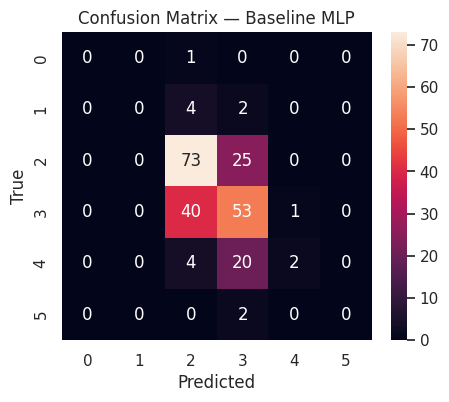

In [26]:
# 3) BASELINE MLP MODEL

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

def report_scores(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

res_baseline = report_scores("Baseline MLP", y_test, y_pred_base)

# Confusion matrix (baseline)
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm_base, annot=True, fmt="d")
plt.title("Confusion Matrix — Baseline MLP")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Fitting 5 folds for each of 54 candidates, totalling 270 fits

 Best Params: {'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128,), 'clf__learning_rate_init': 0.001}
 Best CV Accuracy: 0.5947

===== Tuned MLP =====
Accuracy : 0.5507
Precision: 0.5248
Recall   : 0.5507
F1-score : 0.5297

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.62      0.65      0.63        98
           6       0.50      0.60      0.54        94
           7       0.45      0.19      0.27        26
           8       0.00      0.00      0.00         2

    accuracy                           0.55       227
   macro avg       0.26      0.24      0.24       227
weighted avg       0.52      0.55      0.53       227



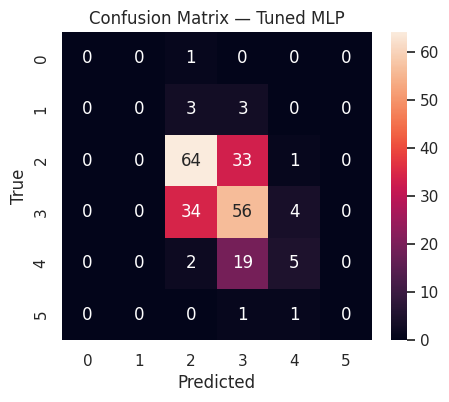

In [33]:
# 4) HYPERPARAMETER TUNING & RUN GRID SEARCH
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", MLPClassifier(
        solver="adam",
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "clf__hidden_layer_sizes": [(64,), (128,), (64,32)],
    "clf__alpha": [1e-4, 1e-3, 1e-2],
    "clf__learning_rate_init": [1e-3, 5e-4, 1e-4],
    "clf__activation": ["relu", "tanh"],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n Best Params:", grid.best_params_)
print(f" Best CV Accuracy: {grid.best_score_:.4f}")
best_mlp = grid.best_estimator_

y_pred_tuned = best_mlp.predict(X_test)
res_tuned = report_scores("Tuned MLP", y_test, y_pred_tuned)

# Confusion matrix (tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt="d")
plt.title("Confusion Matrix — Tuned MLP")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


,Model,Accuracy,Precision,Recall,F1
0,Baseline MLP,0.563877,0.549849,0.563877,0.526252
1,Tuned MLP,0.550661,0.524784,0.550661,0.529660


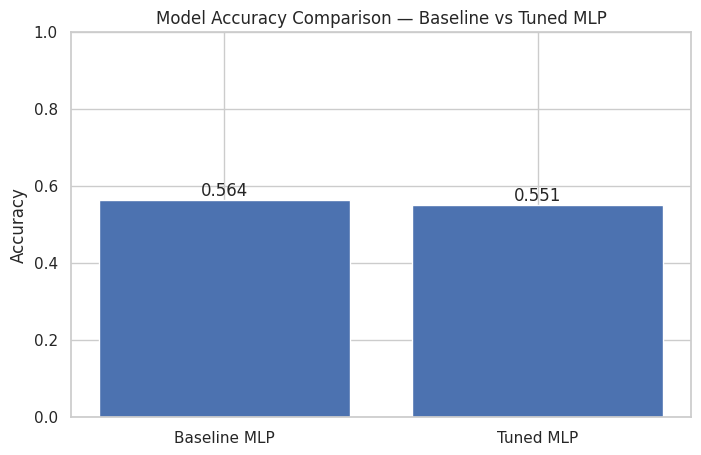

In [34]:
# 6) (OPTIONAL) RE-TRAIN AFTER TUNING
# 7) BASELINE VS TUNED — COMPARISON TABLE & GRAPH
results_df = pd.DataFrame([res_baseline, res_tuned]).sort_values(by="Accuracy", ascending=False)
display(results_df)

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison — Baseline vs Tuned MLP")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(results_df["Accuracy"].values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.show()

In [35]:
# 8) PREDICTION — SINGLE ROW & BATCH
# Fill the example automatically from the first row (easy way to get the structure right)
example = X_train.iloc[0].to_dict()

# Optionally modify some values:


# Predict with the tuned model
single_pred = best_mlp.predict(pd.DataFrame([example]))[0]
print(f"🔮 Single-row prediction (class index): {single_pred}")


if hasattr(best_mlp, "predict_proba"):
    single_proba = best_mlp.predict_proba(pd.DataFrame([example]))[0]
    print("Class probabilities:", single_proba)


# ---- Batch predictions on a new CSV ----

# new_df = pd.read_csv(BATCH_CSV)
# preds = best_mlp.predict(new_df)
# out = new_df.copy()
# out["prediction"] = preds
# out.to_csv("/content/predictions.csv", index=False)
# print("Saved batch predictions to /content/predictions.csv")

🔮 Single-row prediction (class index): 5
Class probabilities: [0.06688775 0.05783983 0.45249652 0.32188646 0.04369078 0.05719867]
